# Structure set: `RS.CPPP.PHANTOM.dcm`

Load the RTSTRUCT with `pydosert` (against the `CPPP/CT` series) and display each ROI
as a contour overlay on the CT.

In [1]:
from pathlib import Path

import numpy as np
import pydicom
import SimpleITK as sitk
import matplotlib.pyplot as plt

from pydosert.data.utils.dicom_utils import load_ct_series, load_structures
from pydosert.utils.plotting import overlay_mask_outline

ct_folder = Path("CPPP/CT")
rtstruct_path = "CPPP/RS.CPPP.PHANTOM.dcm"

# ROI display colours straight from the RTSTRUCT
_rs = pydicom.dcmread(rtstruct_path)
_num_to_name = {r.ROINumber: r.ROIName for r in _rs.StructureSetROISequence}
roi_colors = {
    _num_to_name[c.ReferencedROINumber]: tuple(v / 255 for v in c.ROIDisplayColor)
    for c in _rs.ROIContourSequence
}
print("ROIs in structure set:", roi_colors)


ROIs in structure set: {'BODY': (0.0, 1.0, 0.0), 'Center': (1.0, 0.0, 1.0)}


In [2]:
# Load the CT series (reference grid) and rasterise every ROI onto it.
# NB: pydosert's load_structures needs explicit names (struct_names=None is broken upstream).
ct_image, _ = load_ct_series(ct_folder)
structures = load_structures(ct_image, ct_folder, rtstruct_path, struct_names=list(roi_colors))

ct = sitk.GetArrayFromImage(ct_image)  # (z, y, x) HU
masks = {name: sitk.GetArrayFromImage(img) > 0 for name, img in structures.items()}

print("CT volume (z, y, x):", ct.shape)
for name, m in masks.items():
    zs = np.where(m.any(axis=(1, 2)))[0]
    print(f"  {name:8s}  voxels={m.sum():>8d}  slices {zs.min()}-{zs.max()}")


CT volume (z, y, x): (83, 512, 512)
  BODY      voxels= 9470400  slices 1-81
  Center    voxels=   43349  slices 33-49


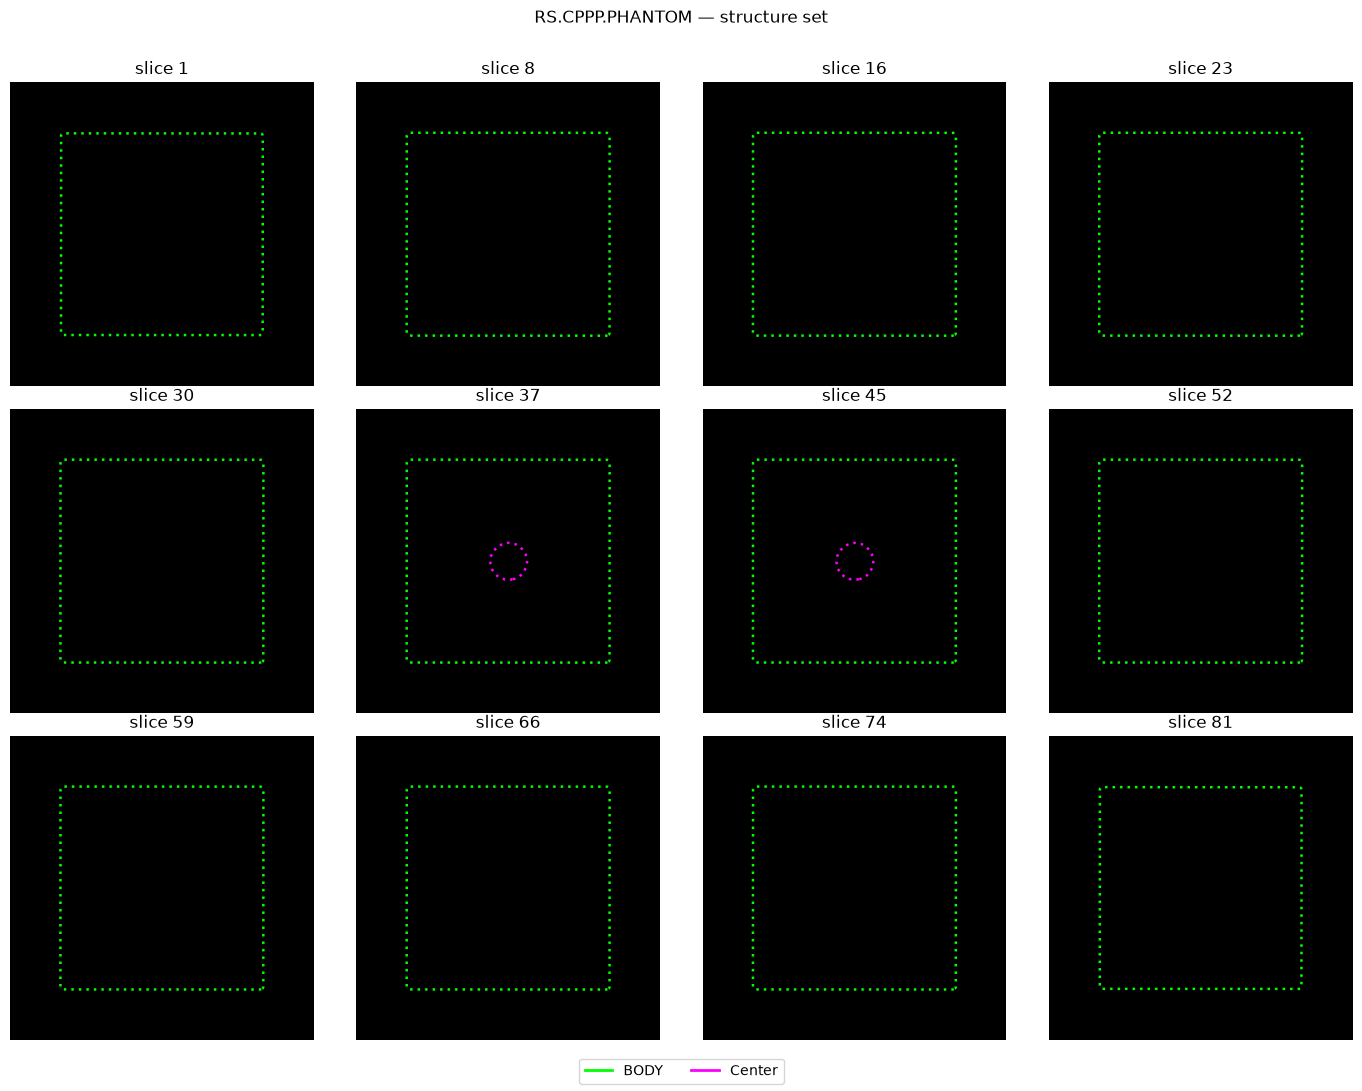

In [3]:
# Axial montage: contour overlays across the slices the structure set covers
union = np.zeros(ct.shape, bool)
for m in masks.values():
    union |= m
zs = np.where(union.any(axis=(1, 2)))[0]
slices = np.linspace(zs.min(), zs.max(), 12).round().astype(int)

fig, axes = plt.subplots(3, 4, figsize=(14, 11))
for ax, z in zip(axes.ravel(), slices):
    ax.imshow(ct[z], cmap="gray", vmin=-200, vmax=300)
    plt.sca(ax)
    for name, m in masks.items():
        if m[z].any():
            overlay_mask_outline(m[z], color=roi_colors.get(name, "red"), linewidth=1.8)
    ax.set_title(f"slice {z}")
    ax.axis("off")

handles = [plt.Line2D([], [], color=roi_colors.get(n, "red"), lw=2, label=n) for n in masks]
fig.legend(handles=handles, loc="lower center", ncol=len(masks))
fig.suptitle("RS.CPPP.PHANTOM — structure set")
fig.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()


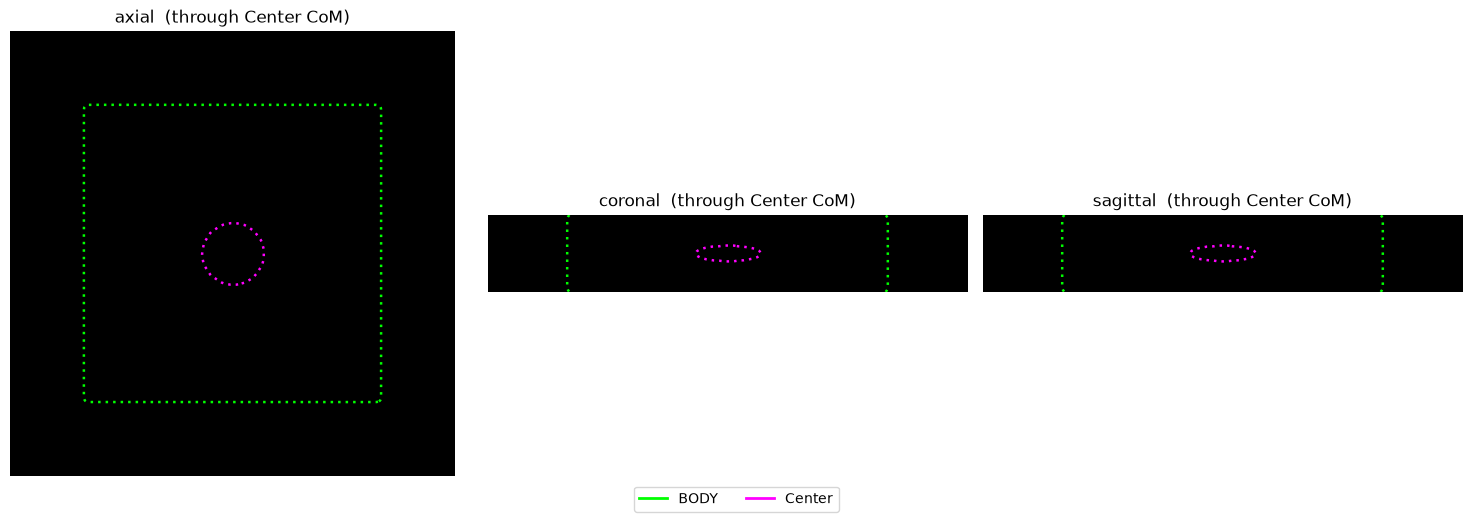

In [4]:
# Orthogonal views through the centre of mass of the smallest ROI
from scipy import ndimage

target = min(masks, key=lambda n: masks[n].sum())
cz, cy, cx = np.array(ndimage.center_of_mass(masks[target])).round().astype(int)

planes = [
    ("axial",    ct[cz, :, :],  lambda m: m[cz, :, :]),
    ("coronal",  ct[:, cy, :],  lambda m: m[:, cy, :]),
    ("sagittal", ct[:, :, cx],  lambda m: m[:, :, cx]),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (title, bg, slc) in zip(axes, planes):
    ax.imshow(bg, cmap="gray", vmin=-200, vmax=300, origin="lower" if title != "axial" else "upper")
    plt.sca(ax)
    for name, m in masks.items():
        sl = slc(m)
        if sl.any():
            overlay_mask_outline(sl, color=roi_colors.get(name, "red"), linewidth=1.8)
    ax.set_title(f"{title}  (through {target} CoM)")
    ax.axis("off")
fig.legend(handles=handles, loc="lower center", ncol=len(masks))
fig.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()
